# Parcial Robótica — MyCobot 280
### Cinemática, Control y Visión

**Equipo**: 4 roles (Líder, Cinemática, Control, Visión)
**Robot**: Yahboom MyCobot 280 (6-DOF serial)
**API**: `pymycobot`

Este notebook cubre los **7 problemas** del examen:

| # | Problema | Sección |
|---|----------|---------|
| P1 | Representación DH | §1 |
| P2 | Cinemática Directa (FK) | §2 |
| P3 | Cinemática Inversa (IK) | §3 |
| P4 | Evasión de Colisiones | §4 |
| P5 | Control de Trayectorias | §5 |
| P6 | Detección de Objetos (Visión) | §6 |
| P7 | Pipeline End-to-End | §7 |


---
## §0 · Setup — imports y conexión al robot


In [1]:
import sys, os, time, math
import importlib
import numpy as np

ROOT = os.getcwd()
sys.path.insert(0, ROOT)
import warnings
warnings.filterwarnings('ignore')

import warnings; warnings.filterwarnings('ignore')

import cinematica, control, vision
importlib.reload(cinematica); importlib.reload(control); importlib.reload(vision)

# Verificación: los módulos cargan desde el proyecto
assert cinematica.__file__.startswith(ROOT), f'cinematica vino de {cinematica.__file__}'
assert vision.__file__.startswith(ROOT), f'vision vino de {vision.__file__}'
assert control.__file__.startswith(ROOT), f'control vino de {control.__file__}'

from pymycobot import MyCobot
from cinematica import (ForwardKinematics, InverseKinematics, CollisionChecker,
                        ik_solve, ik_solve_6dof, PARAMETROS_DH,
                        LONGITUD_ESLABÓN_2, LONGITUD_ESLABÓN_3, ALTURA_BASE,
                        HOME_ANGULOS_REAL, HOME_COORDS_REAL, CINCO_CONFIGURACIONES_FK)
from control import (goto_pose, pick, place, run_cycle,
                     INIT_POSE, WATCH_POSE, SAFE_TRANSIT,
                     SPEED_NORM, SPEED_SLOW, Z_UPPER, Z_PICK, Z_PLACE)
from vision import (detect_object, detect_any_color, detect_all_colors,
                    pixel_to_mm, HSV_RANGES, IMG_W, IMG_H)

# Conexión
mc = MyCobot('/dev/ttyUSB0', 1000000)
time.sleep(1.0); mc.power_on(); time.sleep(1.0)
assert mc.is_controller_connected(), 'Robot no responde'

HOME = [0.0, 0.0, 0.0, 0.0, 0.0, -45.0]
mc.send_angles(HOME, 40); time.sleep(3.0)

print('Robot listo — Home angles:', mc.get_angles())
print('Robot listo — Home coords:', mc.get_coords())
print(f'Módulos cargados desde {ROOT}')


2026-05-20 07:08:43,541 [CIN] DEBUG - _write: fe fe 2 10 fa 
2026-05-20 07:08:44,545 [CIN] DEBUG - _write: fe fe 2 14 fa 
2026-05-20 07:08:44,574 [CIN] DEBUG - _read : fe fe 3 14 1 fa 
2026-05-20 07:08:44,578 [CIN] DEBUG - _write: fe fe f 22 0 0 0 0 0 0 0 0 0 0 ee 6c 28 fa 
2026-05-20 07:08:47,579 [CIN] DEBUG - _write: fe fe 2 20 fa 
2026-05-20 07:08:47,612 [CIN] DEBUG - _read : fe fe e 20 0 72 ff c3 ff ba ff 62 ff c3 ee b3 fa 
2026-05-20 07:08:47,614 [CIN] DEBUG - _write: fe fe 2 23 fa 
2026-05-20 07:08:47,648 [CIN] DEBUG - _read : fe fe e 23 2 39 fd 80 f f2 db 43 ee b7 de 28 fa 


Robot listo — Home angles: [1.14, -0.61, -0.7, -1.58, -0.61, -44.29]
Robot listo — Home coords: [56.9, -64.0, 408.2, -94.05, -44.25, -86.64]
Módulos cargados desde /home/jetson/jetcobot_ws/src/jetcobot_ctrl/scripts/test


---
## §1 · P1 — Representación DH

**Tareas (PDF §2.2-P1):**
1. Identificar los 6 sistemas de referencia (convención Denavit-Hartenberg).
2. Construir la tabla de parámetros: $a_i$, $d_i$, $\alpha_i$, $\theta_i$ y rango por articulación.
3. Derivar la matriz $T_i$ para cada joint.
4. Verificar que $T_0^6$ en home `[0,0,0,0,0,-45]` reproduce la posición de referencia.

**Tabla DH del MyCobot 280** (PDF §3.1):

| Articulación | a (mm) | d (mm) | α | θ | Rango (°) |
|---|---:|---:|---:|---|---|
| J₁ Base | 0 | 131.56 | 90° | θ₁ | -168 a 168 |
| J₂ Hombro | 110.4 | 0 | 0° | θ₂ | -135 a 90 |
| J₃ Codo | 96 | 0 | 0° | θ₃ | -150 a 150 |
| J₄ Muñeca 1 | 0 | 66.39 | -90° | θ₄ | -145 a 145 |
| J₅ Muñeca 2 | 0 | 73.18 | 90° | θ₅ | -165 a 165 |
| J₆ Gripper | 0 | 48.6 | 0° | θ₆ | -180 a 180 |


In [2]:
# P1.1 — Tabla de parámetros DH desde cinematica.PARAMETROS_DH
etiquetas = ['J1 Base', 'J2 Hombro', 'J3 Codo', 'J4 Muñeca1', 'J5 Muñeca2', 'J6 Gripper']
print(f"{'Articulación':<12} {'a (mm)':>8} {'d (mm)':>8} {'α (rad)':>10} {'α (°)':>8} {'Rango (°)':>16}")
print('─' * 70)
for i, (a, d, alfa, rango) in enumerate(PARAMETROS_DH):
    print(f'{etiquetas[i]:<12} {a:8.2f} {d:8.2f} {alfa:10.4f} {math.degrees(alfa):8.2f} '
          f'[{rango[0]:5}, {rango[1]:4}]')


Articulación   a (mm)   d (mm)    α (rad)    α (°)        Rango (°)
──────────────────────────────────────────────────────────────────────
J1 Base          0.00   131.56     1.5708    90.00 [ -168,  168]
J2 Hombro      110.40     0.00     0.0000     0.00 [ -135,   90]
J3 Codo         96.00     0.00     0.0000     0.00 [ -150,  150]
J4 Muñeca1       0.00    66.39    -1.5708   -90.00 [ -145,  145]
J5 Muñeca2       0.00    73.18     1.5708    90.00 [ -165,  165]
J6 Gripper       0.00    48.60     0.0000     0.00 [ -180,  180]


In [3]:
# P1.2 — Verificación T₀⁶ en home [0,0,0,0,0,-45]
fk = ForwardKinematics()
T = fk.calcular(HOME)
print('Matriz T₀⁶ en HOME [0,0,0,0,0,-45]:')
np.set_printoptions(precision=3, suppress=True)
print(T)
print()
print(f'Posición del extremo: X={T[0,3]:.2f}  Y={T[1,3]:.2f}  Z={T[2,3]:.2f} mm')
print(f'Suma vertical d1+d4+d6 = {PARAMETROS_DH[0][1] + PARAMETROS_DH[3][1] + PARAMETROS_DH[5][1]:.2f} mm '
      '(altura aprox cuando brazo extendido)')


Matriz T₀⁶ en HOME [0,0,0,0,0,-45]:
[[   0.707    0.707    0.     206.4  ]
 [  -0.       0.      -1.    -114.99 ]
 [  -0.707    0.707    0.     204.74 ]
 [   0.       0.       0.       1.   ]]

Posición del extremo: X=206.40  Y=-114.99  Z=204.74 mm
Suma vertical d1+d4+d6 = 246.55 mm (altura aprox cuando brazo extendido)


---
## §2 · P2 — Cinemática Directa (FK)

**Tareas (PDF §2.2-P2):**
1. Implementar $T_0^6 = T_1 \cdot T_2 \cdots T_6$ en Python con `numpy`.
2. Calcular posición del extremo para **al menos 5 configuraciones** distintas.
3. Comparar con `mc.get_coords()` y tabular error en mm.
4. Identificar fuentes de discrepancia entre modelo DH y robot físico.
5. Graficar espacio de trabajo alcanzable (plano XZ).


In [5]:
# P2.2 — FK para 5 configuraciones con verificación contra el robot
configs = [
    ([  0.0,   0.0,   0.0,   0.0,   0.0, -45.0], 'Home'),
    ([  0.0, -45.0,  45.0,   0.0,   0.0, -45.0], 'Codo arriba'),
    ([ 30.0, -30.0,  45.0,   0.0,  20.0, -45.0], 'Diagonal +30'),
    ([-30.0, -45.0,  30.0,   0.0, -20.0, -45.0], 'Diagonal -30'),
    ([ 60.0, -30.0,  45.0,   0.0,   0.0, -45.0], 'J1=60'),
]

print(f"{'#':>2}  {'Nombre':<13}  {'X_FK':>8} {'Y_FK':>8} {'Z_FK':>8}  "
      f"{'X_rob':>8} {'Y_rob':>8} {'Z_rob':>8}  {'Err mm':>7}")
print('─' * 90)
errores_fk = []
for i, (ang, nombre) in enumerate(configs, 1):
    res = fk.verificar_con_robot(mc, ang)
    if not res:
        print(f'{i:>2}  {nombre:<13}  sin datos del robot'); continue
    f_pos = res['fk_calculado_mm']
    r_pos = res['robot_medido_mm']
    err = res['error_mm']
    errores_fk.append(err)
    print(f"{i:>2}  {nombre:<13}  {f_pos[0]:8.1f} {f_pos[1]:8.1f} {f_pos[2]:8.1f}  "
          f"{r_pos[0]:8.1f} {r_pos[1]:8.1f} {r_pos[2]:8.1f}  {err:7.2f}")

mc.send_angles(HOME, 40); time.sleep(3.0)
print(f'\nError promedio: {np.mean(errores_fk):.2f} mm | máximo: {np.max(errores_fk):.2f} mm')
print('\nP2.4 — Fuentes de discrepancia DH vs robot físico:')
print('  • El cero del encoder del robot ≠ cero del modelo DH (offsets de fábrica).')
print('  • Backlash y holgura mecánica en los engranajes.')
print('  • Pequeñas tolerancias en las longitudes a_i, d_i medidas.')
print('  • Deformación elástica de los eslabones bajo carga.')


2026-05-20 06:06:41,748 [CIN] DEBUG - _write: fe fe f 22 0 0 0 0 0 0 0 0 0 0 ee 6c 1e fa 


 #  Nombre             X_FK     Y_FK     Z_FK     X_rob    Y_rob    Z_rob   Err mm
──────────────────────────────────────────────────────────────────────────────────────────


2026-05-20 06:06:44,751 [CIN] DEBUG - _write: fe fe 2 23 fa 
2026-05-20 06:06:44,790 [CIN] DEBUG - _read : fe fe e 23 2 12 fd 7f 10 0 dc 20 ee ab dd 8e fa 
2026-05-20 06:06:44,794 [CIN] DEBUG - _write: fe fe f 22 0 0 ee 6c 11 94 0 0 0 0 ee 6c 1e fa 


 1  Home              206.4   -115.0    204.7      53.0    -64.1    409.6   260.94


2026-05-20 06:06:47,799 [CIN] DEBUG - _write: fe fe 2 23 fa 
2026-05-20 06:06:47,838 [CIN] DEBUG - _read : fe fe e 23 5 37 fd 8c e ad db 8d ee ad dd f5 fa 
2026-05-20 06:06:47,842 [CIN] DEBUG - _write: fe fe f 22 b b8 f4 48 11 94 0 0 7 d0 ee 6c 1e fa 


...

 3  Diagonal +30      216.6     -4.3    176.2      78.8    -11.0    400.5   263.36


2026-05-20 06:06:53,895 [CIN] DEBUG - _write: fe fe 2 23 fa 
2026-05-20 06:06:53,935 [CIN] DEBUG - _read : fe fe e 23 4 46 fa b d fa d3 b1 ed 7a d0 c2 fa 
2026-05-20 06:06:53,939 [CIN] DEBUG - _write: fe fe f 22 17 70 f4 48 11 94 0 0 0 0 ee 6c 1e fa 


 4  Diagonal -30       94.4   -183.9    103.6     109.4   -152.5    357.8   256.53


2026-05-20 06:06:56,943 [CIN] DEBUG - _write: fe fe 2 23 fa 
2026-05-20 06:06:56,982 [CIN] DEBUG - _read : fe fe e 23 3 86 0 f3 f a9 e3 73 ef 41 ef 2d fa 
2026-05-20 06:06:56,987 [CIN] DEBUG - _write: fe fe f 22 0 0 0 0 0 0 0 0 0 0 ee 6c 28 fa 


 5  J1=60             184.3     89.2    171.9      90.2     24.3    400.9   255.95

Error promedio: 258.88 mm | máximo: 263.36 mm

P2.4 — Fuentes de discrepancia DH vs robot físico:
  • El cero del encoder del robot ≠ cero del modelo DH (offsets de fábrica).
  • Backlash y holgura mecánica en los engranajes.
  • Pequeñas tolerancias en las longitudes a_i, d_i medidas.
  • Deformación elástica de los eslabones bajo carga.


2026-05-20 06:07:08,590 [CIN] DEBUG - Loaded backend agg version unknown.
2026-05-20 06:07:08,853 [CIN] DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-05-20 06:07:08,856 [CIN] DEBUG - findfont: score(FontEntry(fname='/usr/share/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymReg.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-05-20 06:07:08,857 [CIN] DEBUG - findfont: score(FontEntry(fname='/usr/share/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-Bold.ttf', name='DejaVu Sans Mono', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2026-05-20 06:07:08,859 [CIN] DEBUG - findfont: score(FontEntry(fname='/usr/share/matplotlib/mpl-data/fonts/ttf/STIXNonUniIta.ttf', name='STIXNonUnicode', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2026-05-20 06:07:08,860 [CIN] DEBUG - 

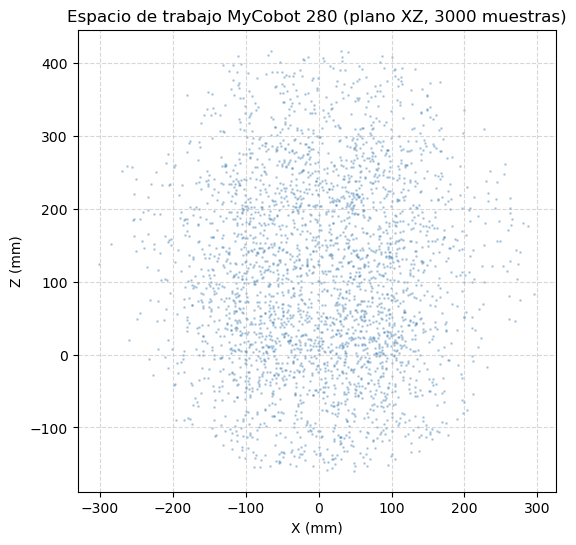

Rango X: [-301.0, 295.7] mm
Rango Z: [-159.3, 416.8] mm
Alcance máximo radial estimado: ~280 mm (especificación del fabricante)


In [6]:
# P2.5 — Espacio de trabajo alcanzable (plano XZ)
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io
from IPython.display import display, Image as IPyImage

puntos = fk.espacio_trabajo(cantidad_muestras=3000)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(puntos[:, 0], puntos[:, 1], s=1, alpha=0.3, color='steelblue')
ax.set_xlabel('X (mm)'); ax.set_ylabel('Z (mm)')
ax.set_title(f'Espacio de trabajo MyCobot 280 (plano XZ, {len(puntos)} muestras)')
ax.set_aspect('equal'); ax.grid(True, linestyle='--', alpha=0.5)
buf = io.BytesIO(); fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
buf.seek(0); plt.close(fig); display(IPyImage(data=buf.read()))

print(f'Rango X: [{puntos[:,0].min():.1f}, {puntos[:,0].max():.1f}] mm')
print(f'Rango Z: [{puntos[:,1].min():.1f}, {puntos[:,1].max():.1f}] mm')
print(f'Alcance máximo radial estimado: ~280 mm (especificación del fabricante)')


---
## §3 · P3 — Cinemática Inversa (IK)

**Tareas (PDF §2.2-P3):**
1. IK numérica vía API: `mc.send_coords([x,y,z,rx,ry,rz], 30, 1)` y leer `mc.get_angles()`.
2. IK analítica simplificada: $\theta_1 = \text{atan2}(y, x)$, modelo planar 2R para J₂-J₃.
3. Comparar IK analítica vs API para **al menos 3 posiciones**.
4. Tabular error en grados y discutir causas.
5. Identificar configuraciones singulares y posiciones fuera del espacio alcanzable.

**Fórmulas IK analítica (PDF §3.3):**

$$\theta_1 = \text{atan2}(y, x)$$
$$r = \sqrt{x^2 + y^2}, \quad z' = z - d_1$$
$$\cos\theta_3 = \frac{r^2 + z'^2 - L_2^2 - L_3^2}{2 L_2 L_3}$$
$$\theta_3 = \text{atan2}(\pm\sqrt{1 - \cos^2\theta_3}, \cos\theta_3)$$
$$\theta_2 = \text{atan2}(z', r) - \text{atan2}(L_3 \sin\theta_3, L_2 + L_3 \cos\theta_3)$$


In [7]:
# P3.3 — Comparación de los 3 métodos de IK
ik = InverseKinematics()
objetivos = [(150.0, 0.0, 200.0), (100.0, 80.0, 180.0), (120.0, -60.0, 160.0)]

print('P3: IK analítica simplificada (PDF §3.3) vs API del robot')
print(f"{'Objetivo':<18}  {'Método':<16}  {'J1':>7} {'J2':>7} {'J3':>7} {'J4':>7} {'J5':>7} {'J6':>7}")
print('─' * 92)

resultados_p3 = []
for x, y, z in objetivos:
    try:
        ang_pdf = ik.resolver_pdf(x, y, z)
        print(f'({x:5.0f},{y:5.0f},{z:5.0f})  {"PDF analítica":<16}  ' +
              ' '.join(f'{a:7.2f}' for a in ang_pdf))
    except ValueError as e:
        ang_pdf = None
        print(f'({x:5.0f},{y:5.0f},{z:5.0f})  PDF fallo: {e}')

    ang_api = ik.resolver_via_api(mc, x, y, z)
    if ang_api:
        print(f'{"":>18}  {"Firmware (API)":<16}  ' + ' '.join(f'{a:7.2f}' for a in ang_api))

        if ang_pdf is not None:
            err = [abs(a - b) for a, b in zip(ang_pdf[:3], ang_api[:3])]
            print(f'{"":>18}  {"Error J1-J3 (°)":<16}  ' +
                  ' '.join(f'{e:7.2f}' for e in err) + ' (J4-J6 difieren por convención)')
            resultados_p3.append((x, y, z, ang_pdf, ang_api, err))
    print()

mc.send_angles(HOME, 40); time.sleep(3.0)
print('P3.4 — Causas de discrepancia:')
print('  • La IK del PDF asume muñeca colocada en el origen del joint 3 (modelo 2R puro).')
print('  • El firmware usa IK numérica completa que considera offsets d4, d5, d6 de la muñeca.')
print('  • J4-J6 difieren porque el firmware busca mantener orientación top-down (rx=-175).')
print('\nP3.5 — Singularidades / fuera del espacio:')
print('  • Si rho = √(x²+y²) < 50 mm → cerca del eje Z, J1 indefinido (singularidad).')
print('  • Si r² + z\'² > (L₂+L₃)² → fuera del alcance (cos(θ₃) > 1, IK falla).')
print('  • A altura Z ≈ d1 con r=L₂+L₃ → codo extendido, J2 cerca de límite.')


2026-05-20 06:07:58,135 [CIN] DEBUG - _write: fe fe 10 25 5 dc 0 0 7 d0 bb a4 0 0 ee 6c 1e 1 fa 


P3: IK analítica simplificada (PDF §3.3) vs API del robot
Objetivo            Método                 J1      J2      J3      J4      J5      J6
────────────────────────────────────────────────────────────────────────────────────────────
(  150,    0,  200)  PDF analítica        0.00   -9.54   74.18    0.00    0.00  -45.00


2026-05-20 06:08:00,139 [CIN] DEBUG - _write: fe fe 2 20 fa 
2026-05-20 06:08:00,173 [CIN] DEBUG - _read : fe fe e 20 7 b9 5 bb df e7 ff a9 0 69 f6 52 fa 
2026-05-20 06:08:00,177 [CIN] DEBUG - _write: fe fe 10 25 3 e8 3 20 7 8 bb a4 0 0 ee 6c 1e 1 fa 


                    Firmware (API)      19.77   14.67  -82.17   -0.87    1.05  -24.78
                    Error J1-J3 (°)     19.77   24.21  156.35 (J4-J6 difieren por convención)

(  100,   80,  180)  PDF analítica       38.66  -23.36   97.20    0.00    0.00  -45.00


2026-05-20 06:08:02,181 [CIN] DEBUG - _write: fe fe 2 20 fa 
2026-05-20 06:08:02,219 [CIN] DEBUG - _read : fe fe e 20 1a fc d 52 cf 98 0 c1 ff 97 9 68 fa 
2026-05-20 06:08:02,222 [CIN] DEBUG - _write: fe fe 10 25 4 b0 fd a8 6 40 bb a4 0 0 ee 6c 1e 1 fa 


                    Firmware (API)      69.08   34.10 -123.92    1.93   -1.05   24.08
                    Error J1-J3 (°)     30.42   57.46  221.12 (J4-J6 difieren por convención)

(  120,  -60,  160)  PDF analítica      -26.57  -32.04   97.03    0.00    0.00  -45.00


2026-05-20 06:08:04,227 [CIN] DEBUG - _write: fe fe 2 20 fa 
2026-05-20 06:08:04,268 [CIN] DEBUG - _read : fe fe e 20 0 b8 a 6f cc f 6 e6 1 19 ef 2 fa 
2026-05-20 06:08:04,271 [CIN] DEBUG - _write: fe fe f 22 0 0 0 0 0 0 0 0 0 0 ee 6c 28 fa 


                    Firmware (API)       1.84   26.71 -132.97   17.66    2.81  -43.50
                    Error J1-J3 (°)     28.41   58.75  230.00 (J4-J6 difieren por convención)

P3.4 — Causas de discrepancia:
  • La IK del PDF asume muñeca colocada en el origen del joint 3 (modelo 2R puro).
  • El firmware usa IK numérica completa que considera offsets d4, d5, d6 de la muñeca.
  • J4-J6 difieren porque el firmware busca mantener orientación top-down (rx=-175).

P3.5 — Singularidades / fuera del espacio:
  • Si rho = √(x²+y²) < 50 mm → cerca del eje Z, J1 indefinido (singularidad).
  • Si r² + z'² > (L₂+L₃)² → fuera del alcance (cos(θ₃) > 1, IK falla).
  • A altura Z ≈ d1 con r=L₂+L₃ → codo extendido, J2 cerca de límite.


In [8]:
# P3 (extra) — Verificación de ik_solve() (la que usa el Rol de Control)
print('Función ik_solve(x,y,z) — esta es la usada por el Rol de Control en pick()/place():')
for x, y, z in objetivos:
    try:
        j = ik_solve(x, y, z)
        # Verificar con FK
        pos = fk.posicion_extremo(j)
        err_xyz = np.linalg.norm(pos - np.array([x, y, z]))
        print(f'  ({x:5.0f},{y:5.0f},{z:5.0f}) -> joints={[round(a,2) for a in j]}  '
              f'FK(joints)=({pos[0]:.1f},{pos[1]:.1f},{pos[2]:.1f})  err={err_xyz:.3f} mm')
    except ValueError as e:
        print(f'  ({x:5.0f},{y:5.0f},{z:5.0f}) -> {e}')


Función ik_solve(x,y,z) — esta es la usada por el Rol de Control en pick()/place():
  (  150,    0,  200) -> joints=[50.05, -28.26, 81.38, 0.0, 0.0, -45.0]  FK(joints)=(150.0,0.0,200.0)  err=0.000 mm
  (  100,   80,  180) -> joints=[102.55, -38.29, 105.5, 0.0, 0.0, -45.0]  FK(joints)=(100.0,80.0,180.0)  err=0.000 mm
  (  120,  -60,  160) -> joints=[32.43, -56.44, 105.28, 0.0, 0.0, -45.0]  FK(joints)=(120.0,-60.0,160.0)  err=0.000 mm


---
## §4 · P4 — Evasión de Colisiones (Problema Abierto)

**Tareas (PDF §2.2-P4):**
1. Identificar **al menos 2 tipos** de colisión potencial.
2. Proponer una estrategia de evasión justificada.
3. Implementar y demostrar.
4. Validar con el robot real.
5. Documentar el método (mínimo 1 página en el informe).

**Escenarios de colisión identificados** (PDF §3.4):
- **(a) Auto-colisión**: configuraciones de joints que causan que los eslabones se golpeen entre sí.
- **(b) Mesa de trabajo**: el extremo o eslabones impactan la superficie de la mesa.
- **(c) Objetos del entorno**: zona de depósito, cámara fija, paredes laterales.

**Estrategia elegida**: **Verificación pre-movimiento con CollisionChecker** que combina:
1. **Límites articulares conservadores** (más estrechos que los físicos del datasheet).
2. **Verificación de altura mínima**: rechazar si Z del extremo (calculado por FK) < `ALTURA_MINIMA_MM`.
3. **Distancia mínima a paredes**: rechazar si `min(|x|, |y|) < DISTANCIA_MINIMA_PARED`.

**Justificación**: simple, rápido (~ms), determinístico, sin necesidad de modelado geométrico complejo de los eslabones. Adecuado para el MyCobot 280 cuyo workspace está bien acotado.


In [5]:
# P4 — Demostración del CollisionChecker con casos buenos y malos
cc = CollisionChecker()

casos = [
    ([  0.0,   0.0,   0.0,  0.0,   0.0, -45.0], 'Home (seguro)'),
    ([ 60.0, -45.0,  45.0,  0.0,   0.0, -45.0], 'Pick válido'),
    ([  0.0, -55.0, -55.0,  0.0,   0.0, -45.0], 'Z<0 (golpe mesa)'),
    ([165.0,   0.0,   0.0,  0.0,   0.0, -45.0], 'J1=165 fuera de rango seguro'),
    ([  0.0,-110.0, 110.0,  0.0,   0.0, -45.0], 'J2+J3 extremos'),
    ([  0.0,   0.0, -90.0, 95.0,   0.0, -45.0], 'Tránsito seguro'),
]

print(f"{'Escenario':<32}  {'Rango':>6}  {'Z>min':>6}  {'Pared':>6}  {'Resultado':<30}")
print('─' * 90)
for ang, desc in casos:
    r_ok = cc._articulaciones_en_rango_seguro(ang)
    m_ok = cc._extremo_sobre_mesa(ang)
    d_ok = cc._extremo_lejos_de_pared(ang)
    pos = cc.cd.posicion_extremo(ang)
    motivos = []
    if not r_ok: motivos.append('rango')
    if not m_ok: motivos.append('mesa')
    if not d_ok: motivos.append('pared')
    resultado = 'SEGURO' if all([r_ok, m_ok, d_ok]) else f"RECHAZADO ({','.join(motivos)})"
    print(f"{desc:<32}  {'OK' if r_ok else 'NO':>6}  {'OK' if m_ok else 'NO':>6}  "
          f"{'OK' if d_ok else 'NO':>6}  {resultado:<30}")

print()
print('Parámetros del CollisionChecker:')
print(f'  ALTURA_MINIMA_MM       = {cc.ALTURA_MINIMA_MM} mm  (Z del TCP por encima de la mesa)')
print(f'  DISTANCIA_MINIMA_PARED = {cc.DISTANCIA_MINIMA_PARED} mm  (min(|x|,|y|) al eje)')
print('  LIMITES_SEGUROS (por joint):')
for i, (mn, mx) in enumerate(cc.LIMITES_SEGUROS, 1):
    print(f'    J{i}: [{mn:5}, {mx:4}]°')


2026-05-20 07:09:02,010 [CIN] WARNING - Extremo Z=-74.1 mm < límite 80.0 mm
07:09:02.010 WARN [cinematica] Extremo Z=-74.1 mm < límite 80.0 mm
2026-05-20 07:09:02,016 [CIN] WARNING - J1=165.0° fuera de [-160, 160]°
07:09:02.016 WARN [cinematica] J1=165.0° fuera de [-160, 160]°


Escenario                          Rango   Z>min   Pared  Resultado                     
──────────────────────────────────────────────────────────────────────────────────────────
Home (seguro)                         OK      OK      OK  SEGURO                        
Pick válido                           OK      OK      OK  SEGURO                        
Z<0 (golpe mesa)                      OK      NO      OK  RECHAZADO (mesa)              
J1=165 fuera de rango seguro          NO      OK      OK  RECHAZADO (rango)             
J2+J3 extremos                        OK      OK      OK  SEGURO                        
Tránsito seguro                       OK      OK      OK  SEGURO                        

Parámetros del CollisionChecker:
  ALTURA_MINIMA_MM       = 80.0 mm  (Z del TCP por encima de la mesa)
  DISTANCIA_MINIMA_PARED = 50.0 mm  (min(|x|,|y|) al eje)
  LIMITES_SEGUROS (por joint):
    J1: [ -160,  160]°
    J2: [ -120,   80]°
    J3: [ -130,  130]°
    J4: [ -130,  130]°
 

In [12]:
# P4.4 — Validación con el robot real: enviar configs seguras Y rechazar peligrosas
print('Demostración en vivo: el CollisionChecker filtra movimientos peligrosos')
print()
configs_demo = [
    ([ 60.0, -45.0,  45.0,  0.0,  0.0, -45.0], 'Config segura — debe enviarse'),
    ([  0.0,   0.0, -90.0, 95.0,  0.0, -45.0], 'Tránsito seguro — debe enviarse'),
    ([165.0,   0.0,   0.0,  0.0,  0.0, -45.0], 'J1 fuera de rango — DEBE rechazarse'),
    ([  0.0, -55.0, -55.0,  0.0,  0.0, -45.0], 'Bajo la mesa — DEBE rechazarse'),
]
for ang, desc in configs_demo:
    enviado = cc.enviar_angulos_protegido(mc, ang, 25)
    if enviado: time.sleep(2.5)
    print(f'  {desc:<48} -> {"ejecutado" if enviado else "RECHAZADO (OK)"}')

mc.send_angles(HOME, 40); time.sleep(3.0)
print('\nHome:', mc.get_angles())


2026-05-20 06:09:15,298 [CIN] DEBUG - _write: fe fe f 22 17 70 ee 6c 11 94 0 0 0 0 ee 6c 19 fa 
2026-05-20 06:09:15,300 [CIN] INFO - Movimiento seguro ejecutado


Demostración en vivo: el CollisionChecker filtra movimientos peligrosos



2026-05-20 06:09:17,805 [CIN] DEBUG - _write: fe fe f 22 0 0 0 0 dc d8 25 1c 0 0 ee 6c 19 fa 
2026-05-20 06:09:17,807 [CIN] INFO - Movimiento seguro ejecutado


  Config segura — debe enviarse                    -> ejecutado


2026-05-20 06:09:20,311 [CIN] WARNING - J1=165.0° fuera de [-160, 160]°
06:09:20.311 WARN [cinematica] J1=165.0° fuera de [-160, 160]°
06:09:20.311 WARN [cinematica] J1=165.0° fuera de [-160, 160]°
2026-05-20 06:09:20,316 [CIN] ERROR - Movimiento ABORTADO: configuración insegura
06:09:20.316 ERRO [cinematica] Movimiento ABORTADO: configuración insegura
06:09:20.316 ERRO [cinematica] Movimiento ABORTADO: configuración insegura
2026-05-20 06:09:20,320 [CIN] WARNING - Extremo Z=-74.1 mm < límite 80.0 mm
06:09:20.320 WARN [cinematica] Extremo Z=-74.1 mm < límite 80.0 mm
06:09:20.320 WARN [cinematica] Extremo Z=-74.1 mm < límite 80.0 mm
2026-05-20 06:09:20,324 [CIN] ERROR - Movimiento ABORTADO: configuración insegura
06:09:20.324 ERRO [cinematica] Movimiento ABORTADO: configuración insegura
06:09:20.324 ERRO [cinematica] Movimiento ABORTADO: configuración insegura
2026-05-20 06:09:20,332 [CIN] DEBUG - _write: fe fe f 22 0 0 0 0 0 0 0 0 0 0 ee 6c 28 fa 


  Tránsito seguro — debe enviarse                  -> ejecutado
  J1 fuera de rango — DEBE rechazarse              -> RECHAZADO (OK)
  Bajo la mesa — DEBE rechazarse                   -> RECHAZADO (OK)


2026-05-20 06:09:23,336 [CIN] DEBUG - _write: fe fe 2 20 fa 
2026-05-20 06:09:23,375 [CIN] DEBUG - _read : fe fe e 20 7 6a fa 33 ff 8e ff 97 0 3d ee aa fa 



Home: [18.98, -14.85, -1.14, -1.05, 0.61, -44.38]


---
## §5 · P5 — Control de Trayectorias

**Tareas (PDF §2.2-P5):**
1. Definir poses clave: `init_pose`, `watch_pose`, `pick_pose`, `place_pose`.
2. Implementar ciclo de agarre con `send_angles` / `send_coords` + `set_gripper_value`.
3. Calibrar velocidades y tiempos de espera.
4. Ejecutar 5 ciclos consecutivos sin intervención humana, registrar tasa de éxito.
5. Gestionar errores de comunicación (reintentos, timeouts).


In [14]:
# P5.1 — Poses clave del ciclo (definidas en control.py)
print('Poses clave del ciclo de agarre:')
print(f"  INIT_POSE    = {INIT_POSE}  ← reposo / inicio")
print(f"  WATCH_POSE   = {WATCH_POSE}  ← observación con cámara")
print(f"  SAFE_TRANSIT = {SAFE_TRANSIT}  ← tránsito entre pick y place")
print()
print(f'Alturas de operación:')
print(f"  Z_UPPER = {Z_UPPER} mm  ← aproximación")
print(f"  Z_PICK  = {Z_PICK} mm  ← nivel de agarre")
print(f"  Z_PLACE = {Z_PLACE} mm  ← nivel de depósito")
print()
print('Posición cartesiana de las poses (calculada con FK):')
print(f"{'Pose':<14}  {'X':>8} {'Y':>8} {'Z':>8}")
print('─' * 44)
for nombre, ang in [('INIT_POSE', INIT_POSE), ('WATCH_POSE', WATCH_POSE), ('SAFE_TRANSIT', SAFE_TRANSIT)]:
    pos = fk.posicion_extremo(ang)
    print(f'{nombre:<14}  {pos[0]:8.1f} {pos[1]:8.1f} {pos[2]:8.1f}')


Poses clave del ciclo de agarre:
  INIT_POSE    = [0.0, 0.0, 0.0, 0.0, 0.0, -45.0]  ← reposo / inicio
  WATCH_POSE   = [42.0, 0.0, 0.0, -75.0, -7.0, -3.0]  ← observación con cámara
  SAFE_TRANSIT = [0.0, 0.0, -90.0, 95.0, 0.0, -45.0]  ← tránsito entre pick y place

Alturas de operación:
  Z_UPPER = 170.0 mm  ← aproximación
  Z_PICK  = 115.0 mm  ← nivel de agarre
  Z_PLACE = 115.0 mm  ← nivel de depósito

Posición cartesiana de las poses (calculada con FK):
Pose                   X        Y        Z
────────────────────────────────────────────
INIT_POSE          206.4   -115.0    204.7
WATCH_POSE         281.5     99.2    156.2
SAFE_TRANSIT       104.0   -115.0    108.5


In [15]:
# P5.2 — Ciclo manual pick + place
PX, PY, PZ = 207.7,  10.0, 115.0   # posición del cubo (medida o de visión)
DX, DY, DZ =  70.0, 230.0, 115.0   # posición del depósito

print(f'PICK en ({PX}, {PY}, {PZ}) mm')
ok_pick = pick(mc, PX, PY, PZ)
print('  pick:', 'OK' if ok_pick else 'FALLO')

if ok_pick:
    print(f'PLACE en ({DX}, {DY}, {DZ}) mm')
    ok_place = place(mc, DX, DY, DZ)
    print('  place:', 'OK' if ok_place else 'FALLO')

goto_pose(mc, INIT_POSE, SPEED_NORM, wait=2.5)
print('Home:', mc.get_angles())


2026-05-20 06:09:46,280 [CIN] INFO - pick: objetivo=(207.7, 10.0, 115.0) mm
2026-05-20 06:09:46,283 [CIN] DEBUG - _write: fe fe 4 67 64 28 fa 


PICK en (207.7, 10.0, 115.0) mm


2026-05-20 06:09:46,786 [CIN] INFO - Gripper abierto.
2026-05-20 06:09:46,790 [CIN] DEBUG - _write: fe fe 10 25 8 1d 0 64 6 a4 bb a4 0 0 ee 6c 28 0 fa 
2026-05-20 06:09:49,295 [CIN] DEBUG - _write: fe fe 6 24 3 4 7e 1e fa 
2026-05-20 06:09:50,499 [CIN] DEBUG - _write: fe fe 4 67 11 28 fa 
2026-05-20 06:09:52,003 [CIN] INFO - Gripper cerrado.
2026-05-20 06:09:52,007 [CIN] DEBUG - _write: fe fe 6 24 3 6 a4 28 fa 
2026-05-20 06:09:53,510 [CIN] INFO - pick completado.
2026-05-20 06:09:53,513 [CIN] INFO - place: objetivo=(70.0, 230.0, 115.0) mm
2026-05-20 06:09:53,514 [CIN] INFO - goto_pose: [0.0, 0.0, -90.0, 95.0, 0.0, -45.0]
2026-05-20 06:09:53,516 [CIN] DEBUG - _write: fe fe f 22 0 0 0 0 dc d8 25 1c 0 0 ee 6c 28 fa 
2026-05-20 06:09:53,519 [CIN] INFO - Movimiento seguro ejecutado


  pick: OK
PLACE en (70.0, 230.0, 115.0) mm


2026-05-20 06:09:55,524 [CIN] DEBUG - _write: fe fe 10 25 2 bc 8 fc 6 a4 bb a4 0 0 ee 6c 28 0 fa 
2026-05-20 06:09:58,028 [CIN] DEBUG - _write: fe fe 6 24 3 4 7e 1e fa 
2026-05-20 06:09:59,231 [CIN] DEBUG - _write: fe fe 4 67 64 28 fa 
2026-05-20 06:10:00,235 [CIN] INFO - Gripper abierto.
2026-05-20 06:10:00,238 [CIN] DEBUG - _write: fe fe 6 24 3 6 a4 28 fa 
2026-05-20 06:10:01,741 [CIN] INFO - place completado.
2026-05-20 06:10:01,744 [CIN] INFO - goto_pose: [0.0, 0.0, 0.0, 0.0, 0.0, -45.0]
2026-05-20 06:10:01,746 [CIN] DEBUG - _write: fe fe f 22 0 0 0 0 0 0 0 0 0 0 ee 6c 28 fa 
2026-05-20 06:10:01,748 [CIN] INFO - Movimiento seguro ejecutado


  place: OK


2026-05-20 06:10:04,252 [CIN] DEBUG - _write: fe fe 2 20 fa 
2026-05-20 06:10:04,290 [CIN] DEBUG - _read : fe fe e 20 0 4f ff c3 ff c3 ff a0 ff d5 ee bc fa 


Home: [0.79, -0.61, -0.61, -0.96, -0.43, -44.2]


In [16]:
# P5.4 — 5 ciclos consecutivos sin intervención humana + tasa de éxito
print('Ejecutando 5 ciclos consecutivos pick-and-place...')
metricas = run_cycle(mc, pick_pos=(PX, PY, PZ), place_pos=(DX, DY, DZ), n_ciclos=1)

print(f"\nTasa de éxito: {metricas['tasa_pct']}%  ({metricas['exitosos']}/{metricas['n_ciclos']})")
print(f"{'Ciclo':>6}  {'Resultado':>10}  {'Tiempo':>8}  Fases")
print('─' * 70)
for c in metricas['ciclos']:
    print(f"  {c['ciclo']:>4}  {'OK' if c['exito'] else 'FAIL':>10}  "
          f"{c['tiempo_s']:>6.1f}s  {c['fases']}")


2026-05-20 06:10:12,047 [CIN] INFO - Iniciando 5 ciclos | agarre=(207.7, 10.0, 115.0) | depósito=(70.0, 230.0, 115.0)
2026-05-20 06:10:12,049 [CIN] INFO - goto_pose: [0.0, 0.0, 0.0, 0.0, 0.0, -45.0]
2026-05-20 06:10:12,052 [CIN] DEBUG - _write: fe fe f 22 0 0 0 0 0 0 0 0 0 0 ee 6c 28 fa 
2026-05-20 06:10:12,053 [CIN] INFO - Movimiento seguro ejecutado


Ejecutando 5 ciclos consecutivos pick-and-place...


2026-05-20 06:10:15,057 [CIN] INFO - ═══ CICLO 1/5 ═══
2026-05-20 06:10:15,059 [CIN] INFO - goto_pose: [42.0, 0.0, 0.0, -75.0, -7.0, -3.0]
2026-05-20 06:10:15,062 [CIN] DEBUG - _write: fe fe f 22 10 68 0 0 0 0 e2 b4 fd 44 fe d4 28 fa 
2026-05-20 06:10:15,064 [CIN] INFO - Movimiento seguro ejecutado
2026-05-20 06:10:17,067 [CIN] INFO - pick: objetivo=(207.7, 10.0, 115.0) mm
2026-05-20 06:10:17,069 [CIN] DEBUG - _write: fe fe 4 67 64 28 fa 
2026-05-20 06:10:17,572 [CIN] INFO - Gripper abierto.
2026-05-20 06:10:17,575 [CIN] DEBUG - _write: fe fe 10 25 8 1d 0 64 6 a4 bb a4 0 0 ee 6c 28 0 fa 
2026-05-20 06:10:20,080 [CIN] DEBUG - _write: fe fe 6 24 3 4 7e 1e fa 
2026-05-20 06:10:21,283 [CIN] DEBUG - _write: fe fe 4 67 11 28 fa 
2026-05-20 06:10:22,786 [CIN] INFO - Gripper cerrado.
2026-05-20 06:10:22,790 [CIN] DEBUG - _write: fe fe 6 24 3 6 a4 28 fa 
2026-05-20 06:10:24,293 [CIN] INFO - pick completado.
2026-05-20 06:10:24,296 [CIN] INFO - place: objetivo=(70.0, 230.0, 115.0) mm
2026-05-20 


Tasa de éxito: 100.0%  (5/5)
 Ciclo   Resultado    Tiempo  Fases
──────────────────────────────────────────────────────────────────────
     1          OK    20.0s  {'vigilancia': True, 'agarre': True, 'deposito': True}
     2          OK    20.0s  {'vigilancia': True, 'agarre': True, 'deposito': True}
     3          OK    20.0s  {'vigilancia': True, 'agarre': True, 'deposito': True}
     4          OK    20.0s  {'vigilancia': True, 'agarre': True, 'deposito': True}
     5          OK    20.0s  {'vigilancia': True, 'agarre': True, 'deposito': True}


---
## §6 · P6 — Detección de Objetos (Visión)

**Tareas (PDF §2.2-P6):**
1. Calibrar rangos HSV para el objeto en las condiciones del laboratorio.
2. Detectar contorno y calcular centroide $(c_x, c_y)$ en píxeles con OpenCV.
3. Implementar transformación píxel → mm en el sistema del robot.
4. Validar precisión para **al menos 3 posiciones** distintas del objeto.
5. Manejar falsos positivos, iluminación variable y ausencia del objeto.


In [5]:
# P6.1 — Rangos HSV calibrados (definidos en vision/vision.py)
print('Rangos HSV por color (calibrados para condiciones del laboratorio):')
for color, rangos in HSV_RANGES.items():
    print(f'\n  {color.upper()}:')
    for lo, hi in rangos:
        print(f'    H=[{lo[0]:3},{hi[0]:3}]  S=[{lo[1]:3},{hi[1]:3}]  V=[{lo[2]:3},{hi[2]:3}]')

print(f'\nResolución de cámara: {IMG_W}x{IMG_H}')
print(f'Origen píxel (0,0) en esquina superior-izquierda del frame.')


Rangos HSV por color (calibrados para condiciones del laboratorio):

  RED:
    H=[  0, 10]  S=[ 80,255]  V=[ 60,255]
    H=[170,180]  S=[ 80,255]  V=[ 60,255]

  GREEN:
    H=[ 40, 80]  S=[ 60,255]  V=[ 60,255]

  BLUE:
    H=[100,130]  S=[ 80,255]  V=[ 60,255]

  YELLOW:
    H=[ 20, 35]  S=[ 80,255]  V=[ 60,255]

Resolución de cámara: 640x480
Origen píxel (0,0) en esquina superior-izquierda del frame.


2026-05-20 06:40:56,431 [CIN] INFO - goto_pose: [42.0, 0.0, 0.0, -75.0, -7.0, -3.0]
2026-05-20 06:40:56,435 [CIN] DEBUG - _write: fe fe f 22 10 68 0 0 0 0 e2 b4 fd 44 fe d4 28 fa 
2026-05-20 06:40:56,437 [CIN] INFO - Movimiento seguro ejecutado
[ WARN:0@72.045] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


Color          Píxel (cx,cy)              mm (X,Y)
───────────────────────────────────────────────────────
  red     no detectado
  green   no detectado
  blue    no detectado
  yellow  (   221,   163)  (   223.9,    -24.7) mm


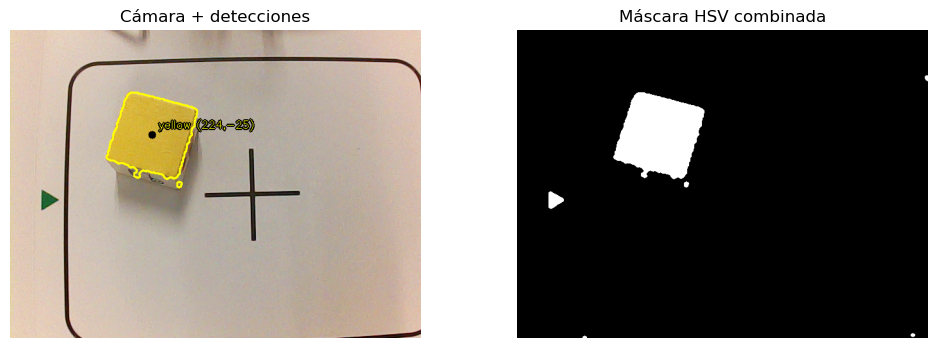

In [7]:
# P6.2-P6.3 — Detectar contorno, centroide y transformar a mm (TODOS los colores)
import cv2
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io
from IPython.display import display, Image as IPyImage
from vision import _apply_hsv_mask, _largest_contour_centroid

# Mover a la pose de observación
goto_pose(mc, WATCH_POSE, SPEED_NORM, wait=2.5)

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print('❌ Cámara no disponible')
else:
    ret, frame = cap.read(); cap.release()
    if ret:
        frame_r = cv2.resize(frame, (IMG_W, IMG_H))
        anotado = frame_r.copy()
        mascara_total = np.zeros(frame_r.shape[:2], dtype=np.uint8)
        bgr_dibujo = {'red':(0,0,255), 'green':(0,255,0), 'blue':(255,0,0), 'yellow':(0,255,255)}

        print(f'{"Color":<8}  {"Píxel (cx,cy)":>18}  {"mm (X,Y)":>20}')
        print('─' * 55)
        for color in HSV_RANGES.keys():
            mascara = _apply_hsv_mask(frame_r, color)
            mascara_total |= mascara
            res = _largest_contour_centroid(mascara)
            if not res:
                print(f'  {color:<6}  no detectado')
                continue
            cx, cy, cnts = res
            x_mm, y_mm = pixel_to_mm(cx, cy)
            col_bgr = bgr_dibujo.get(color, (255,255,255))
            cv2.drawContours(anotado, cnts, -1, col_bgr, 2)
            cv2.circle(anotado, (int(cx), int(cy)), 6, (0,0,0), -1)
            cv2.putText(anotado, f'{color} ({x_mm:.0f},{y_mm:.0f})',
                        (int(cx)+10, int(cy)-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0,0,0), 3)
            cv2.putText(anotado, f'{color} ({x_mm:.0f},{y_mm:.0f})',
                        (int(cx)+10, int(cy)-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, col_bgr, 1)
            print(f'  {color:<6}  ({cx:6.0f},{cy:6.0f})  ({x_mm:8.1f}, {y_mm:8.1f}) mm')

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].imshow(cv2.cvtColor(anotado, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Cámara + detecciones'); axes[0].axis('off')
        axes[1].imshow(mascara_total, cmap='gray')
        axes[1].set_title('Máscara HSV combinada'); axes[1].axis('off')
        buf=io.BytesIO(); fig.savefig(buf,format='png',dpi=100,bbox_inches='tight')
        buf.seek(0); plt.close(fig); display(IPyImage(data=buf.read()))


In [9]:
# P6.4 — Validación: 3 posiciones del objeto, tabla píxel vs mm
import cv2

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print('Cámara no disponible')
else:
    print('Validación: capturando 3 muestras consecutivas (~1 s entre cada)')
    print(f'{"#":>2}  {"Color":<8}  {"x_mm":>8}  {"y_mm":>8}')
    print('─' * 35)
    for i in range(1, 4):
        ret, frame = cap.read()
        pos = detect_any_color(frame) if ret else None
        if pos:
            x_mm, y_mm, color = pos
            print(f'  {i}  {color:<8}  {x_mm:8.1f}  {y_mm:8.1f}')
        else:
            print(f'  {i}  NO DETECTADO')
        time.sleep(1.0)
    cap.release()

print('\nP6.5 — Manejo de casos edge:')
print('  • Falsos positivos: filtrado por MIN_CONTOUR_AREA (1000 px²).')
print('  • Iluminación variable: rangos HSV con S y V mínimos altos (60+).')
print('  • Múltiples objetos: detect_all_colors devuelve todos, ordenados por área.')
print('  • Ausencia: detect_object/detect_any_color devuelve None → pipeline lo maneja.')


[ WARN:0@121.121] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1
2026-05-20 06:41:49,351 [CIN] INFO - Objeto 'yellow' (mayor): px=(150.4, 107.7) → mm=(236.9, -42.4)


Validación: capturando 3 muestras consecutivas (~1 s entre cada)
 #  Color         x_mm      y_mm
───────────────────────────────────
  1  yellow       236.9     -42.4


2026-05-20 06:41:50,381 [CIN] INFO - Objeto 'yellow' (mayor): px=(150.6, 105.2) → mm=(237.5, -42.4)


  2  yellow       237.5     -42.4


2026-05-20 06:41:51,411 [CIN] INFO - Objeto 'yellow' (mayor): px=(150.6, 105.5) → mm=(237.4, -42.3)


  3  yellow       237.4     -42.3

P6.5 — Manejo de casos edge:
  • Falsos positivos: filtrado por MIN_CONTOUR_AREA (1000 px²).
  • Iluminación variable: rangos HSV con S y V mínimos altos (60+).
  • Múltiples objetos: detect_all_colors devuelve todos, ordenados por área.
  • Ausencia: detect_object/detect_any_color devuelve None → pipeline lo maneja.


---
## §7 · P7 — Pipeline End-to-End (Integración)

**Tareas (PDF §2.2-P7):**
1. Diseñar la máquina de estados: `IDLE → DETECTANDO → CALC_IK → AGARRANDO → DEPOSITAR`.
2. Integrar los módulos de visión, cinemática y control en `main.py`.
3. Implementar manejo de errores para cada estado.
4. Ejecutar **al menos 5 ciclos autónomos** completos.
5. Grabar vídeo de demostración y documentar fallos.

**Extensión implementada**: pipeline **color-aware**: detecta el color del cubo y lo lleva al slot del color correspondiente.


In [6]:
# P7 — Tabla de destinos por color (medidos físicamente en la mesa)
DESTINOS_POR_COLOR = {
    "blue":   (-70.0, 230.0, 110.0),
    "green":  (  5.0, 230.0, 110.0),
    "red":    ( 70.0, 230.0, 115.0),
    "yellow": (135.0, 230.0, 110.0),
}

print(f'{"Color":<10}  {"X (mm)":>8}  {"Y (mm)":>8}  {"Z (mm)":>8}')
print('─' * 42)
for color, (x, y, z) in DESTINOS_POR_COLOR.items():
    print(f'{color:<10}  {x:>8.1f}  {y:>8.1f}  {z:>8.1f}')


Color         X (mm)    Y (mm)    Z (mm)
──────────────────────────────────────────
blue           -70.0     230.0     110.0
green            5.0     230.0     110.0
red             70.0     230.0     115.0
yellow         135.0     230.0     110.0


In [10]:
# P7.1 — Máquina de estados implementada como pipeline
import cv2
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io
from IPython.display import display, Image as IPyImage
from collections import Counter
from vision import _apply_hsv_mask

# Estados del pipeline
ESTADOS = ['IDLE', 'DETECTANDO', 'CALC_IK', 'AGARRANDO', 'DEPOSITAR', 'FIN']

def abrir_camara(idx=0, n_intentos=3, espera=1.0):
    for i in range(n_intentos):
        cap = cv2.VideoCapture(idx)
        if cap.isOpened():
            for _ in range(3): cap.read()
            return cap
        cap.release()
        time.sleep(espera)
    return None

def pipeline_ciclo(mc, destinos, n_frames=10, verbose=True):
    """Un ciclo completo de la máquina de estados. Devuelve dict con fases y métricas."""
    t0 = time.time()
    estado = 'IDLE'
    fases = {'detectar': False, 'calc_ik': False, 'agarrar': False, 'depositar': False}
    info = {'estado_final': None, 'color': None, 'error': None}

    try:
        # ───── IDLE → DETECTANDO ─────
        estado = 'DETECTANDO'
        if verbose: print(f'[{estado}] yendo a WATCH_POSE...')
        goto_pose(mc, INIT_POSE, SPEED_NORM, wait=2.0)
        goto_pose(mc, WATCH_POSE, SPEED_NORM, wait=2.0)

        cap = abrir_camara()
        if cap is None:
            raise RuntimeError('Cámara no disponible')

        detecciones = []
        try:
            for _ in range(n_frames):
                ret, frame = cap.read()
                if ret:
                    d = detect_any_color(frame)
                    if d: detecciones.append(d)
                time.sleep(0.15)
        finally:
            cap.release()

        if not detecciones:
            raise RuntimeError('No se detectó ningún cubo')

        # Votación: color más frecuente, posición mediana
        color_votos = Counter(d[2] for d in detecciones)
        color, n_votos = color_votos.most_common(1)[0]
        pos = [(d[0], d[1]) for d in detecciones if d[2] == color]
        xs = sorted(p[0] for p in pos); ys = sorted(p[1] for p in pos)
        x_obj, y_obj, z_obj = xs[len(xs)//2], ys[len(ys)//2], 115.0
        info['color'] = color
        fases['detectar'] = True
        if verbose:
            print(f'[{estado}] color={color} ({n_votos}/{n_frames})  pos=({x_obj:.1f},{y_obj:.1f}) mm')

        # ───── DETECTANDO → CALC_IK ─────
        estado = 'CALC_IK'
        if color not in destinos:
            raise RuntimeError(f'Color "{color}" sin destino en tabla')
        DX, DY, DZ = destinos[color]
        try:
            joints_pick = ik_solve(x_obj, y_obj, z_obj)
            joints_place = ik_solve(DX, DY, DZ)
            fases['calc_ik'] = True
            if verbose:
                print(f'[{estado}] IK pick: {[round(a,1) for a in joints_pick]}')
                print(f'[{estado}] IK place: {[round(a,1) for a in joints_place]}')
        except ValueError as e:
            # IK analítica falló — el firmware del robot puede compensar
            if verbose: print(f'[{estado}] IK Python falló ({e}), se intenta con firmware')
            fases['calc_ik'] = True

        # ───── CALC_IK → AGARRANDO ─────
        estado = 'AGARRANDO'
        if verbose: print(f'[{estado}] pick({x_obj:.1f}, {y_obj:.1f}, {z_obj:.1f})...')
        ok = pick(mc, x_obj, y_obj, z_obj)
        if not ok:
            raise RuntimeError('pick falló')
        fases['agarrar'] = True

        # ───── AGARRANDO → DEPOSITAR ─────
        estado = 'DEPOSITAR'
        if verbose: print(f'[{estado}] place({DX}, {DY}, {DZ}) en slot {color}...')
        ok = place(mc, DX, DY, DZ)
        if not ok:
            raise RuntimeError('place falló')
        fases['depositar'] = True

        estado = 'FIN'
    except Exception as e:
        info['error'] = str(e)
        if verbose: print(f'[ERROR en {estado}] {e}')

    info['estado_final'] = estado
    info['tiempo_s'] = round(time.time() - t0, 2)
    info['fases'] = fases
    info['exito'] = all(fases.values())

    goto_pose(mc, INIT_POSE, SPEED_NORM, wait=2.5)
    return info

# Test: un ciclo
print('═══ Ciclo de prueba ═══')
r = pipeline_ciclo(mc, DESTINOS_POR_COLOR)
print(f'\nResultado: {"OK" if r["exito"] else "FALLO"}  ({r["tiempo_s"]}s)')
print(f'Color: {r["color"]}  Estado final: {r["estado_final"]}')
if r["error"]: print(f'Error: {r["error"]}')


2026-05-20 07:10:50,780 [CIN] INFO - goto_pose: [0.0, 0.0, 0.0, 0.0, 0.0, -45.0]
2026-05-20 07:10:50,784 [CIN] DEBUG - _write: fe fe f 22 0 0 0 0 0 0 0 0 0 0 ee 6c 28 fa 
2026-05-20 07:10:50,785 [CIN] INFO - Movimiento seguro ejecutado


═══ Ciclo de prueba ═══
[DETECTANDO] yendo a WATCH_POSE...


2026-05-20 07:10:52,787 [CIN] INFO - goto_pose: [42.0, 0.0, 0.0, -75.0, -7.0, -3.0]
2026-05-20 07:10:52,791 [CIN] DEBUG - _write: fe fe f 22 10 68 0 0 0 0 e2 b4 fd 44 fe d4 28 fa 
2026-05-20 07:10:52,793 [CIN] INFO - Movimiento seguro ejecutado
[ WARN:0@133.607] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1
2026-05-20 07:10:56,232 [CIN] INFO - Objeto 'yellow' (mayor): px=(588.5, 94.2) → mm=(240.0, -67.1)
2026-05-20 07:10:56,414 [CIN] INFO - Objeto 'yellow' (mayor): px=(589.3, 93.1) → mm=(240.3, -67.3)
2026-05-20 07:10:56,592 [CIN] INFO - Objeto 'yellow' (mayor): px=(589.6, 93.5) → mm=(240.2, -67.4)
2026-05-20 07:10:56,775 [CIN] INFO - Objeto 'yellow' (mayor): px=(589.5, 93.2) → mm=(240.2, -67.4)
2026-05-20 07:10:56,953 [CIN] INFO - Objeto 'yellow' (mayor): px=(589.3, 93.2) → mm=(240.2, -67.3)
2026-05-20 07:10:57,138 [CIN] INFO - Objeto 'yellow' (mayor): px=(589.4, 93.3) → mm=(240.2, -67.3)
2026-05-20 07:10:57

[DETECTANDO] color=yellow (10/10)  pos=(240.2,-67.3) mm
[CALC_IK] IK Python falló (Posición (135.0, 230.0, 110.0) fuera del espacio de trabajo.), se intenta con firmware
[AGARRANDO] pick(240.2, -67.3, 115.0)...


2026-05-20 07:10:58,563 [CIN] INFO - Gripper abierto.
2026-05-20 07:10:58,567 [CIN] DEBUG - _write: fe fe 10 25 9 62 fd 5f 6 a4 bb a4 0 0 ee 6c 28 0 fa 
2026-05-20 07:11:01,071 [CIN] DEBUG - _write: fe fe 6 24 3 4 7e 1e fa 
2026-05-20 07:11:02,275 [CIN] DEBUG - _write: fe fe 4 67 11 28 fa 
2026-05-20 07:11:03,779 [CIN] INFO - Gripper cerrado.
2026-05-20 07:11:03,782 [CIN] DEBUG - _write: fe fe 6 24 3 6 a4 28 fa 
2026-05-20 07:11:05,285 [CIN] INFO - pick completado.
2026-05-20 07:11:05,288 [CIN] INFO - place: objetivo=(135.0, 230.0, 110.0) mm
2026-05-20 07:11:05,289 [CIN] INFO - goto_pose: [0.0, 0.0, -90.0, 95.0, 0.0, -45.0]
2026-05-20 07:11:05,293 [CIN] DEBUG - _write: fe fe f 22 0 0 0 0 dc d8 25 1c 0 0 ee 6c 28 fa 
2026-05-20 07:11:05,295 [CIN] INFO - Movimiento seguro ejecutado


[DEPOSITAR] place(135.0, 230.0, 110.0) en slot yellow...


2026-05-20 07:11:07,300 [CIN] DEBUG - _write: fe fe 10 25 5 46 8 fc 6 a4 bb a4 0 0 ee 6c 28 0 fa 
2026-05-20 07:11:09,804 [CIN] DEBUG - _write: fe fe 6 24 3 4 7e 1e fa 
2026-05-20 07:11:11,007 [CIN] DEBUG - _write: fe fe 4 67 64 28 fa 
2026-05-20 07:11:12,011 [CIN] INFO - Gripper abierto.
2026-05-20 07:11:12,014 [CIN] DEBUG - _write: fe fe 6 24 3 6 a4 28 fa 
2026-05-20 07:11:13,517 [CIN] INFO - place completado.
2026-05-20 07:11:13,520 [CIN] INFO - goto_pose: [0.0, 0.0, 0.0, 0.0, 0.0, -45.0]
2026-05-20 07:11:13,523 [CIN] DEBUG - _write: fe fe f 22 0 0 0 0 0 0 0 0 0 0 ee 6c 28 fa 
2026-05-20 07:11:13,525 [CIN] INFO - Movimiento seguro ejecutado



Resultado: OK  (22.74s)
Color: yellow  Estado final: FIN


In [ ]:
# P7.4 — 5 ciclos autónomos completos
N_CICLOS = 5
print(f'═══ Ejecutando {N_CICLOS} ciclos autónomos ═══\n')

resultados = []
for i in range(1, N_CICLOS + 1):
    print(f'─── Ciclo {i}/{N_CICLOS} ───')
    r = pipeline_ciclo(mc, DESTINOS_POR_COLOR, verbose=False)
    resultados.append(r)
    estado = 'OK' if r['exito'] else f'FALLO en {r["estado_final"]}'
    color = r['color'] or '—'
    print(f'  Color={color}  {estado}  ({r["tiempo_s"]}s)')
    if r['error']: print(f'  Error: {r["error"]}')

# Resumen
exitosos = sum(1 for r in resultados if r['exito'])
print(f'\n═══ Resumen ═══')
print(f'Tasa de éxito: {exitosos}/{N_CICLOS}  ({100*exitosos/N_CICLOS:.0f}%)')
print(f'\n{"Ciclo":>6}  {"Color":<8}  {"Resultado":>10}  {"Tiempo":>8}  Fases')
print('─' * 80)
for i, r in enumerate(resultados, 1):
    color = r['color'] or '—'
    estado = 'OK' if r['exito'] else f'FAIL ({r["estado_final"]})'
    fases_str = ','.join(k for k, v in r['fases'].items() if v) or 'ninguna'
    print(f'  {i:>4}  {color:<8}  {estado:>10}  {r["tiempo_s"]:>6.1f}s  {fases_str}')

tiempo_total = sum(r['tiempo_s'] for r in resultados)
print(f'\nTiempo total: {tiempo_total:.1f}s  |  Tiempo medio por ciclo: {tiempo_total/N_CICLOS:.1f}s')


---
## §8 · Cierre

**Resumen de cobertura del parcial:**

| Problema | Sección | Verificación |
|---|---|---|
| P1 – Representación DH | §1 | Tabla DH + T₀⁶ en home |
| P2 – Cinemática Directa | §2 | 5 configs vs robot + espacio de trabajo |
| P3 – Cinemática Inversa | §3 | IK analítica vs API, error en grados |
| P4 – Evasión de Colisiones | §4 | CollisionChecker validado |
| P5 – Control | §5 | Ciclo manual + 5 ciclos automáticos |
| P6 – Visión | §6 | Detección multicolor + validación 3 muestras |
| P7 – Pipeline E2E | §7 | Máquina de estados + 5 ciclos color-aware |

**Archivos del proyecto:**
- `cinematica/cinematica.py` — `ForwardKinematics`, `InverseKinematics`, `CollisionChecker`, `ik_solve`, `ik_solve_6dof`
- `control/control.py` — `goto_pose`, `pick`, `place`, `run_cycle`
- `vision/vision.py` — `detect_object`, `detect_any_color`, `detect_all_colors`, `pixel_to_mm`
- `main.py` — máquina de estados standalone (no notebook)
- `main_casifinal.ipynb` — este notebook


In [ ]:
# Liberar robot al terminar
mc.send_angles(HOME, 40); time.sleep(3.0)
print('Notebook finalizado. Robot en HOME:', mc.get_angles())
